In [ ]:
from backend.utils.gmsh_function import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from backend.utils.file_path import *
from backend.efield.efield2 import *

In [2]:
name = "monopole"
# Define the path to save the file
path = setup_save_file_paths(name)

In [3]:
L_plate = 2.0
W_plate = 2.0
Hight_monopole = 1.0
W_monopole = 0.02

depart_plate_x = -L_plate / 2
depart_plate_y = -W_plate / 2
depart_plate_z = 0

depart_monopole_x = -W_monopole / 2
depart_monopole_y = 0
depart_monopole_z = 0

In [4]:
light_speed = 3e8

frequency = 75e6
wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

initial_mesh_size = wavelength / 10
print(f"initial_mesh_size = {initial_mesh_size} Meter")

feed_point = np.array([[0, 0, 0]])

wavelength = 4.0 Meter
initial_mesh_size = 0.4 Meter


In [5]:
gmsh.initialize()
gmsh.model.add("Momopole_Antenna")
setup_performance_config()

plate = gmsh.model.occ.addRectangle(-L_plate / 2, -W_plate / 2, 0, L_plate, W_plate)

# Create the monopole
M_P1 = gmsh.model.occ.addPoint(depart_monopole_x, depart_monopole_y, depart_monopole_z)
M_P2 = gmsh.model.occ.addPoint(depart_monopole_x + W_monopole, depart_monopole_y, depart_monopole_z)
M_P3 = gmsh.model.occ.addPoint(depart_monopole_x + W_monopole, depart_monopole_y, depart_monopole_z + Hight_monopole)
M_P4 = gmsh.model.occ.addPoint(depart_monopole_x, depart_monopole_y, depart_monopole_z + Hight_monopole)

M_L1 = gmsh.model.occ.addLine(M_P1, M_P2)
M_L2 = gmsh.model.occ.addLine(M_P2, M_P3)
M_L3 = gmsh.model.occ.addLine(M_P3, M_P4)
M_L4 = gmsh.model.occ.addLine(M_P4, M_P1)

Loop_monopole = gmsh.model.occ.addCurveLoop([M_L1, M_L2, M_L3, M_L4])
Surface_monopole = gmsh.model.occ.addPlaneSurface([Loop_monopole])

# Merge the two surfaces
monopole_antenna, _ = gmsh.model.occ.fuse([(2, plate)], [(2, Surface_monopole)])

gmsh.model.occ.synchronize()

generate_and_save_mesh(path, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/monopole.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/monopole.msh successfully


In [6]:
_ = radiation_algorithm(path, frequency, feed_point, excitation_unit_vector='z', gap_width=1.1*initial_mesh_size)

In [ ]:
print("Calculating radiation intensity distribution over sphere surface...")
radiation_intensity_distribution_over_sphere_surface(path)

Calculating radiation intensity distribution over sphere surface...
MODE SELECTED: radiation
Frequency = 7.50e+07 Hz | Wavelength lambda = 3.9967 m

[Antenna Results]
  Total Radiated Power : 0.0018 W
  Max Gain : 1.2674 (1.03 dBi)
  Radiation Resistance : 0.0036 Ohms
  Total Efficiency : 0.36 %
Data saved successfully to data/antennas_gain_power/monopole_gain_power.mat


In [8]:
display_rhcp_gain(path)
display_lhcp_gain(path)


--- CALCULATING RHCP GAIN (RADIATION MODE) ---
Frequency = 7.50e+07 Hz | Wavelength lambda = 3.9967 m
Total Power : 0.0018 W
Max RHCP Gain : -1.8437 dBic
  Radiation Resistance : 0.0036 Ohms
  Total Efficiency : 0.36 %
Data saved successfully to data/antennas_gain_power/monopole_polar_rhcp_gain_power.mat



--- CALCULATING LHCP GAIN (RADIATION MODE) ---
Frequency = 7.50e+07 Hz | Wavelength lambda = 3.9967 m
Total Power : 0.0018 W
Max LHCP Gain : -1.8582 dBic
  Radiation Resistance : 0.0036 Ohms
  Total Efficiency : 0.36 %
Data saved successfully to data/antennas_gain_power/monopole_polar_lhcp_gain_power.mat


Generating antenna directivity pattern...
Data loaded from data/antennas_gain_power/monopole_gain_power.mat


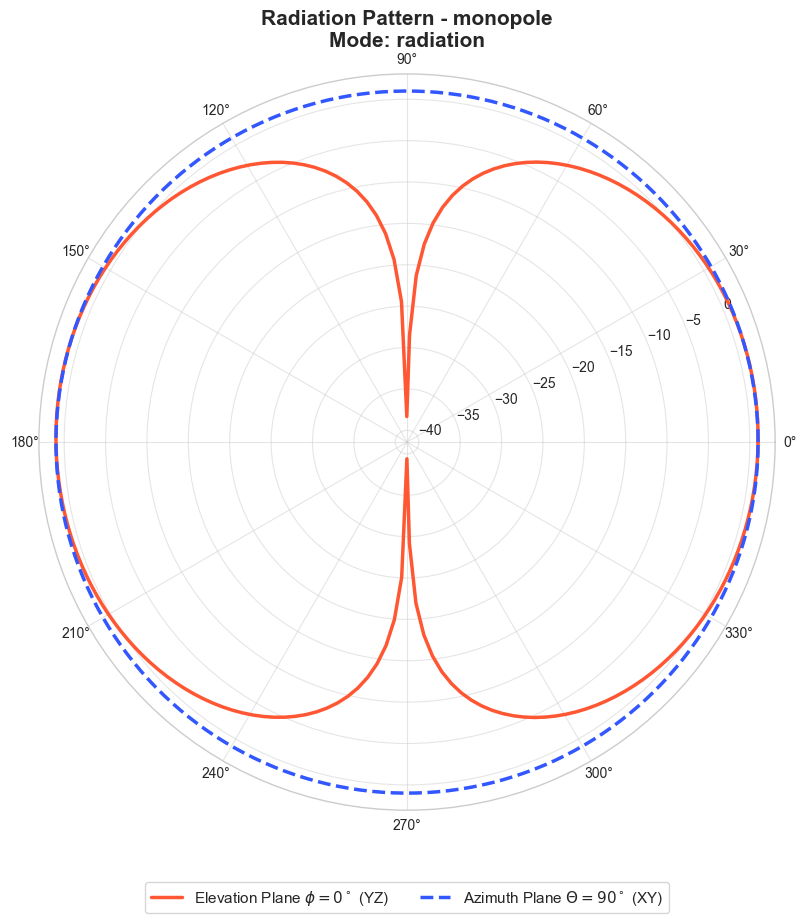

In [9]:
# Step 3: Generating the directivity pattern
from backend.efield.efield3 import *


print("Generating antenna directivity pattern...")
antenna_directivity_pattern(path, mode='radiation')

--- GENERATING RHCP POLAR PATTERN ---
Data loaded from data/antennas_gain_power/monopole_polar_rhcp_gain_power.mat


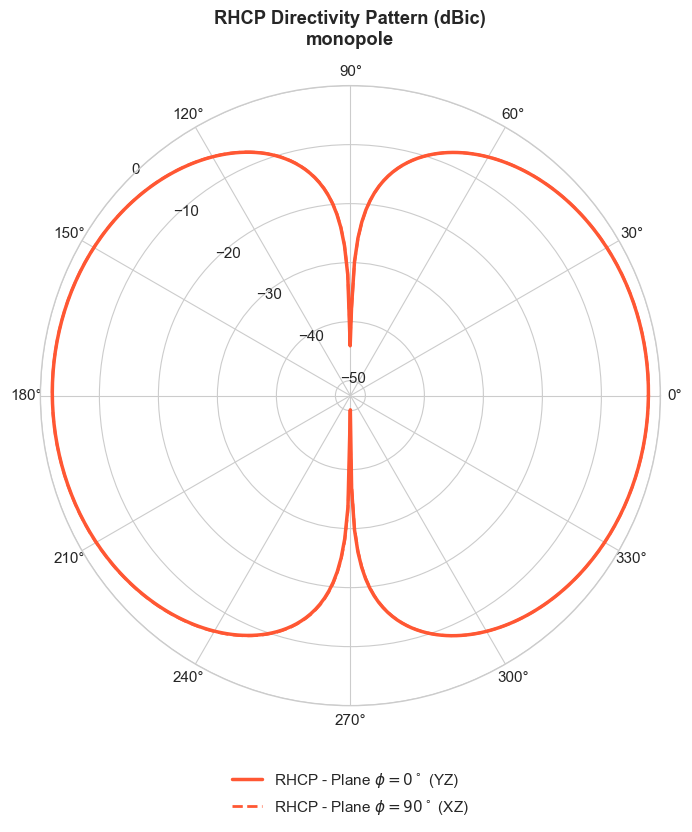

In [10]:
display_rhcp_polar_pattern(path)

--- GENERATING RHCP POLAR PATTERN ---
Data loaded from data/antennas_gain_power/monopole_polar_rhcp_gain_power.mat


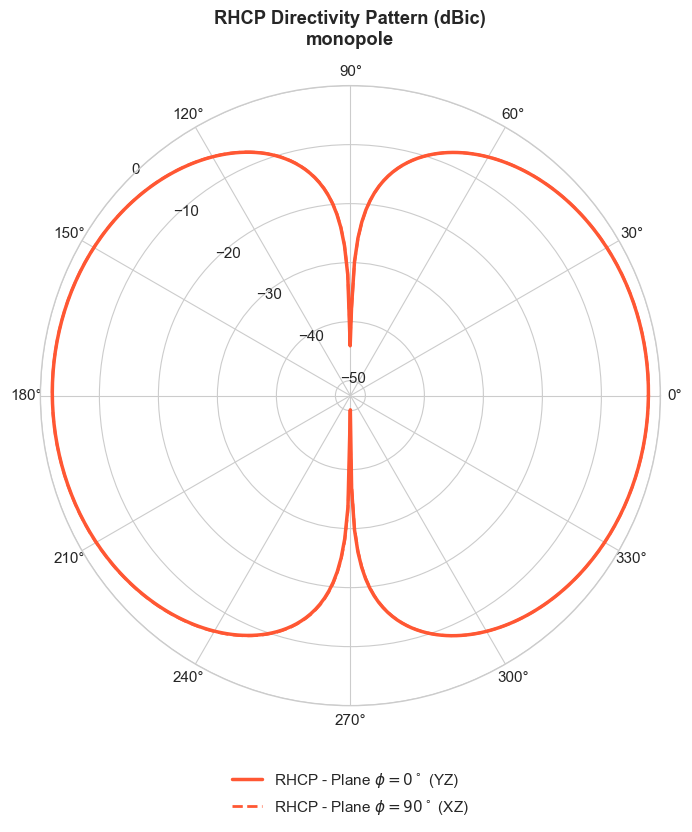

In [11]:
display_rhcp_polar_pattern(path)

from backend.utils.h_refinement_loop    import *

# Mesh refinement setup
grid_points, radius_vicinity = generate_embedded_grid(path.geo)
config = initialize_refinement_config(initial_mesh_size, iterations=5)
# view_grid_point(path.geo, grid_points)

run_radiation_refinement(config, grid_points, radius_vicinity, path, frequency, feed_point, excitation_unit_vector='z', gap_width=1.1*initial_mesh_size)